In [5]:
#pip install jupyterquiz

In [6]:
from jupyterquiz import display_quiz
from IPython.display import HTML

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Question-1

In [10]:
def escape_velocity(M, R):
    G = 6.674 * 10**-11  # gravitational constant
    v = np.sqrt((2 * G * M) / R)
    return v

In [11]:
# Earth values
mass_earth = 5.972 * 10**24  # kg
radius_earth = 6.371 * 10**6  # meters

v_earth = escape_velocity(mass_earth, radius_earth)
print(f"Earth's Escape Velocity: {v_earth:.2f} m/s")

Earth's Escape Velocity: 11185.73 m/s


# Question-2

In [12]:
from astropy.time import Time
from astropy.coordinates import EarthLocation

In [13]:
# 2025-08-08 00:00 UTC time
t = Time("2025-08-08 00:00:00", scale='utc')

# Location: İstanbul
istanbul = EarthLocation(lat=41.01, lon=28.97, height=0)


In [14]:
lst = t.sidereal_time('apparent', longitude=istanbul.lon)
print(f"Local Sidereal Time in Istanbul: {lst}")


Local Sidereal Time in Istanbul: 23.048514584931656 hourangle


# Question-3

In [15]:
# Universal gravitational constant
G = 6.674 * 10**-11  # N m² / kg²

# Earth's mass and radius
M = 5.972 * 10**24   # in kg
R = 6.371 * 10**6    # in meters

# Escape velocity
v_escape = np.sqrt((2 * G * M) / R)

print(f"Escape velocity for Earth: {v_escape:.2f} m/s")

Escape velocity for Earth: 11185.73 m/s


# Question 4

In [16]:
def estimate_pi(n_points):
    x = np.random.uniform(0, 1, n_points)
    y = np.random.uniform(0, 1, n_points)

    # Distance from origin (0,0)
    inside_circle = x**2 + y**2 <= 1

    pi_estimate = 4 * np.sum(inside_circle) / n_points
    return pi_estimate


In [17]:
pi_value = estimate_pi(1000000)
print(f"Estimated value of π: {pi_value}")


Estimated value of π: 3.137472


In [18]:
import matplotlib.pyplot as plt

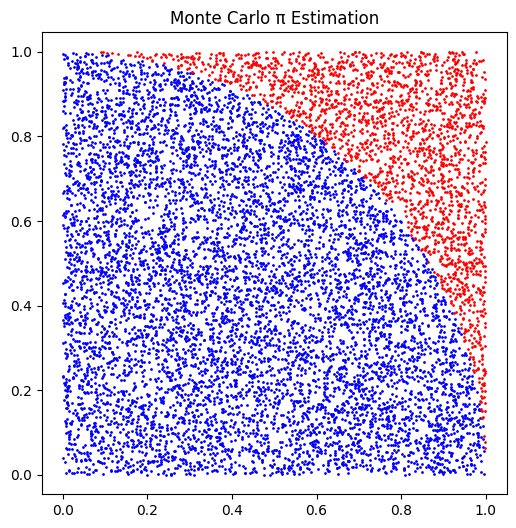

In [19]:
n_points = 10000
x = np.random.uniform(0, 1, n_points)
y = np.random.uniform(0, 1, n_points)

inside = x**2 + y**2 <= 1

plt.figure(figsize=(6,6))
plt.scatter(x[inside], y[inside], color='blue', s=1)
plt.scatter(x[~inside], y[~inside], color='red', s=1)
plt.title("Monte Carlo π Estimation")
plt.axis("equal")
plt.show()


In [20]:
# True model function
def true_function(x, a, b, c):
    return a * x**2 + b * x + c


In [21]:
# Create x values
x = np.linspace(-10, 10, 100)

# Create true y values and add noise
y_true = true_function(x, 1.0, 2.0, 3.0)
noise = np.random.normal(0, 10, size=y_true.shape)
y_noisy = y_true + noise


In [23]:
from scipy.optimize import curve_fit

In [24]:
# Fit the noisy data to the model
popt, pcov = curve_fit(true_function, x, y_noisy)

# popt contains the fitted parameters: a, b, c
print("Fitted parameters:", popt)


Fitted parameters: [1.03013379 1.94915318 0.8032142 ]


In [25]:
# True model function
def true_function(x, a, b, c):
    return a * x**2 + b * x + c


In [26]:
# Create x values
x = np.linspace(-10, 10, 100)

# Create true y values and add noise
y_true = true_function(x, 1.0, 2.0, 3.0)
noise = np.random.normal(0, 10, size=y_true.shape)
y_noisy = y_true + noise


In [27]:
# Fit the noisy data to the model
popt, pcov = curve_fit(true_function, x, y_noisy)

# popt contains the fitted parameters: a, b, c
print("Fitted parameters:", popt)


Fitted parameters: [0.97582724 2.25835169 2.78601564]


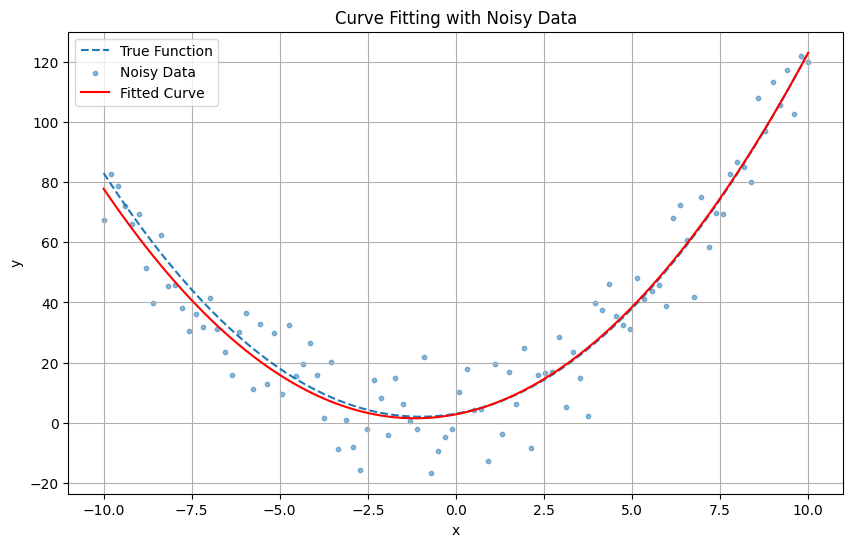

In [28]:
# Generate fitted curve
y_fit = true_function(x, *popt)

# Plot everything
plt.figure(figsize=(10, 6))
plt.plot(x, y_true, label="True Function", linestyle="--")
plt.scatter(x, y_noisy, label="Noisy Data", s=10, alpha=0.5)
plt.plot(x, y_fit, label="Fitted Curve", color="red")
plt.legend()
plt.title("Curve Fitting with Noisy Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


# Question-6

In [29]:
# Simulate a fake spectrum: wavelength from 400 to 800 nm (visible light)
wavelength = np.linspace(400, 800, 1000)  # in nanometers
flux = np.exp(-0.5 * ((wavelength - 550)/30)**2)  # Gaussian "emission" around 550 nm

# Add some noise
flux += np.random.normal(0, 0.02, size=flux.shape)


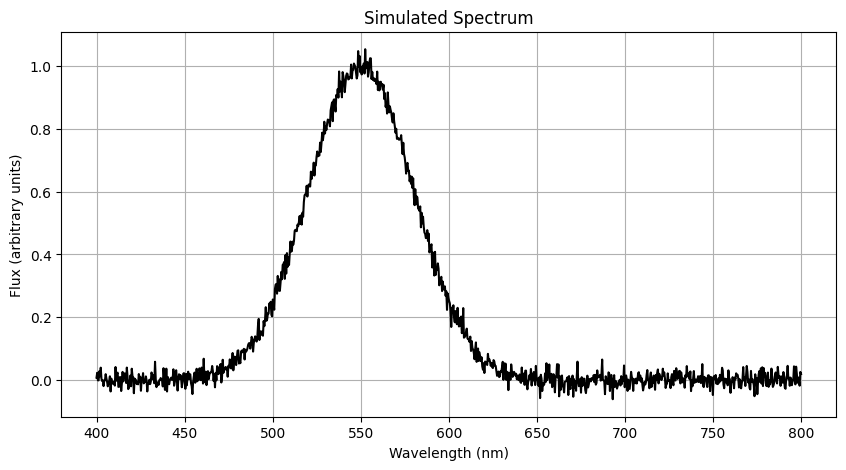

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(wavelength, flux, color='black')
plt.title("Simulated Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux (arbitrary units)")
plt.grid(True)
plt.show()


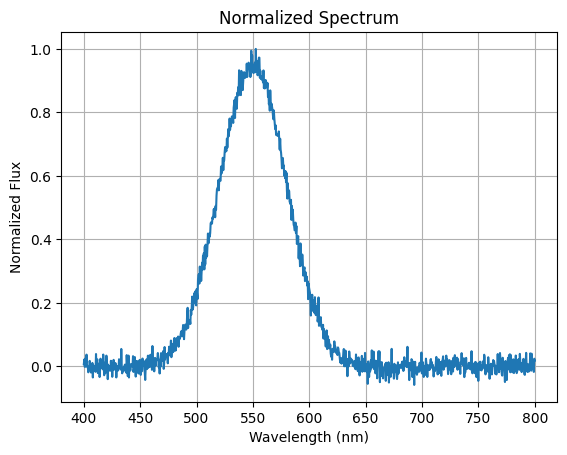

In [31]:
flux_norm = flux / np.max(flux)
plt.plot(wavelength, flux_norm)
plt.title("Normalized Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Flux")
plt.grid(True)
plt.show()


# Question-7

In [32]:
from astropy.io import fits

In [33]:
import matplotlib.pyplot as plt

In [34]:
from astropy.utils.data import download_file

# Download a sample FITS file
url = 'https://astropy.stsci.edu/data/tutorials/FITS-images/HorseHead.fits'
fits_path = download_file(url, cache=True)

In [35]:
# Open the file
hdul = fits.open(fits_path)

Filename: /root/.astropy/cache/download/url/5cf9719609d3ac509bafb58d3469eb73/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


In [36]:
# Show structure
hdul.info()


Filename: /root/.astropy/cache/download/url/5cf9719609d3ac509bafb58d3469eb73/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


In [37]:
image_data = hdul[0].data
header = hdul[0].header
hdul.close()


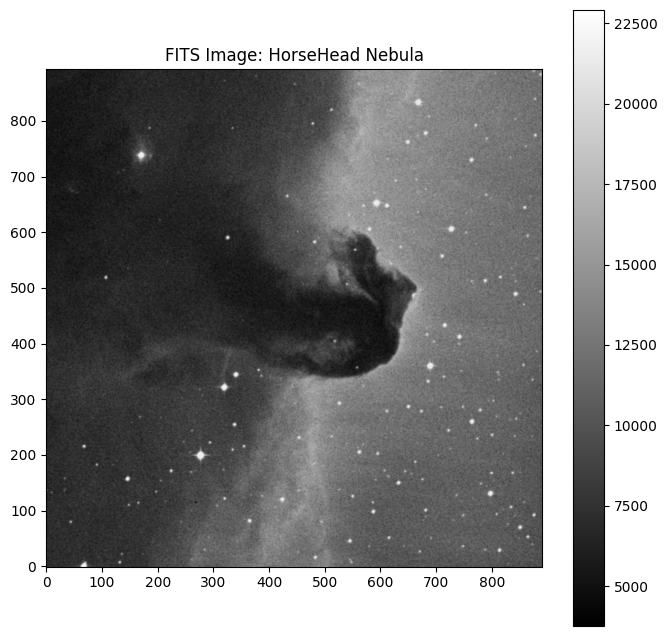

In [38]:
plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap='gray', origin='lower')
plt.colorbar()
plt.title("FITS Image: HorseHead Nebula")
plt.show()


# Question-8

In [39]:
from scipy.signal import find_peaks

In [40]:
# Simulate wavelength range and flat flux
wavelength = np.linspace(400, 700, 1000)
flux = np.ones_like(wavelength)

# Add artificial emission lines
flux += np.exp(-0.5 * ((wavelength - 500)/2)**2) * 3
flux += np.exp(-0.5 * ((wavelength - 656.28)/1.5)**2) * 5  # H-alpha
flux += np.random.normal(0, 0.1, size=flux.shape)  # noise


In [41]:
# Detect emission peaks
peaks, _ = find_peaks(flux, height=1.5, distance=20)


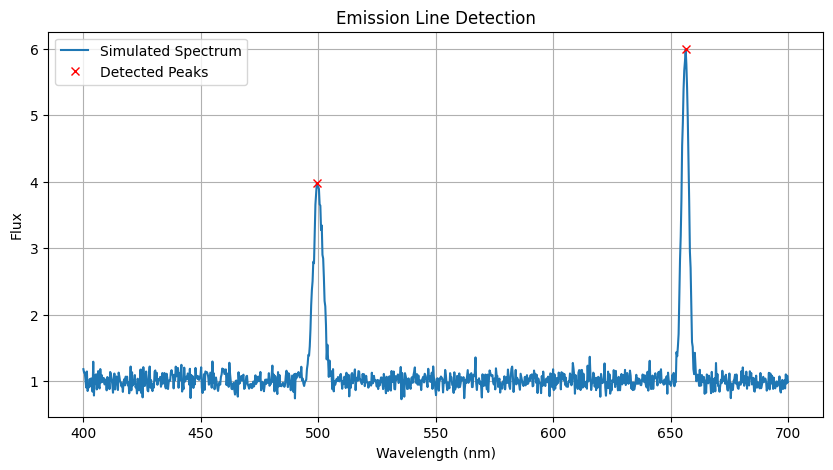

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(wavelength, flux, label='Simulated Spectrum')
plt.plot(wavelength[peaks], flux[peaks], 'rx', label='Detected Peaks')
plt.title("Emission Line Detection")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.show()


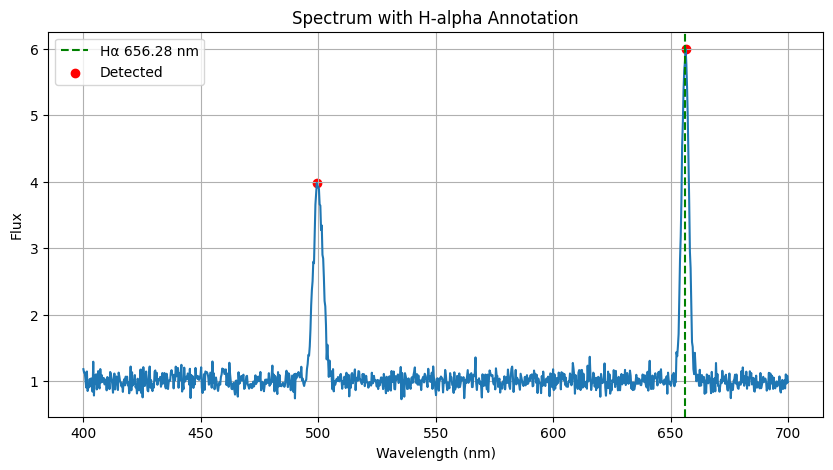

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(wavelength, flux)
plt.axvline(656.28, color='green', linestyle='--', label='Hα 656.28 nm')
plt.scatter(wavelength[peaks], flux[peaks], color='red', label='Detected')
plt.legend()
plt.title("Spectrum with H-alpha Annotation")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
plt.grid(True)
plt.show()


# Question-9

##  Astronomy & Astrophysics Notebook Summary

In this notebook, we explored several fundamental concepts and methods in astrophysics using Python and libraries like **Numpy**, **Matplotlib**, **Scipy**, and **Astropy**:

1. **Escape Velocity**: We calculated the minimum speed required to escape a planet’s gravitational field.
2. **Sidereal Time**: We computed the local sidereal time for Istanbul using Astropy.
3. **Monte Carlo Simulation**: Estimated the value of π by simulating random points in a unit square.
4. **Curve Fitting**: Fit a quadratic function to noisy data using `scipy.optimize.curve_fit`.
5. **Spectral Simulation**: Created a synthetic spectrum and plotted flux vs. wavelength.
6. **FITS File Handling**: Loaded and displayed real astronomical image data from a FITS file.
7. **Feature Detection in Spectra**: Detected emission lines and identified the Hα line at 656.28 nm.

This notebook demonstrates how programming can be applied to simulate, analyze, and visualize real astronomical phenomena.

---
